# imports and constants

In [1]:
import os
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

from psm_final import Algonauts, TripleN, noise_ceiling

# SET UP YOUR ENVIRONMENT VARIABLES

NSD_MAT = "../nsd_expdesign.mat"
ALGONAUTS_DIR = os.environ["ALGONAUTS_DIR"]
TRIPLE_N_DIR = os.environ["TRIPLE_N_DIR"]

**COLAB SETUP**
- import your branch
- your changes have to be on Github, meaning you have to push your branch
- put the data somewhere in Google or have a script to download it at runtime

In [2]:
# !pip install git+https://github.com/lucas-nunn/PSM-NeuroAI-Final.git@triple-n-algonauts

# from glob import glob

# from google.colab import drive

# drive.mount('/content/drive/', force_remount=True)
# main_dir = '/content/drive/MyDrive/PSM NeuroAI Project'
# ALGONAUTS_DIR = os.path.join(main_dir, 'data/algonauts')
# TRIPLE_N_DIR = os.path.join(main_dir, 'data/triple_n')

# assert os.path.isdir(main_dir)

# glob(fmri_dir+'/*')

# loading files

In [3]:
# get the 1000 shared image indexes from the NSD experiment design mat file

exp = sio.loadmat(NSD_MAT)
sharedix = exp["sharedix"].flatten()
shared_ids = set((sharedix).tolist()) # convert to 0-based indexing

In [4]:
# get the fmri data for subject 01 from the Algonauts dataset

subj01_lh = np.load(f"{ALGONAUTS_DIR}/subj01/training_split/training_fmri/lh_training_fmri.npy")
subj01_rh = np.load(f"{ALGONAUTS_DIR}/subj01/training_split/training_fmri/rh_training_fmri.npy")

In [5]:
sesh_1 = sio.loadmat(f"{TRIPLE_N_DIR}/Processed/Processed_ses01_240629_M1_2.mat")
sesh_1.keys()

dict_keys(['__header__', '__version__', '__globals__', 'B_SI', 'F_SI', 'O_SI', 'UnitNum', 'UnitType', 'best_r_time1', 'best_r_time2', 'mean_psth', 'pos', 'r_search_pool', 'reliability_basic', 'reliability_best', 'reliability_find_testset', 'response_basic', 'response_best', 'snr', 'snrmax'])

# Algonauts RDMs

<Figure size 500x400 with 0 Axes>

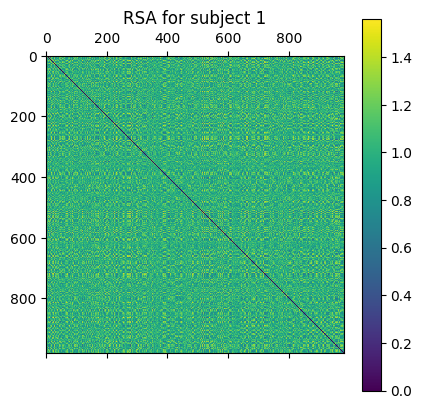

In [6]:
algonauts = Algonauts(ALGONAUTS_DIR, shared_ids)
dist = algonauts.compute_rdm(subject=1)

plt.figure(figsize=(5,4))
plt.matshow(squareform(dist))
plt.title(f'RSA for subject 1')
plt.colorbar()
plt.show()

In [7]:
dist2 = algonauts.compute_rdm(subject=2)
rho_, pval = spearmanr(dist, dist2)

print(f"Spearman correlation between subject 1 and 2 RDMs: {rho_:.4f}, p-value: {pval:.4e}")

Spearman correlation between subject 1 and 2 RDMs: 0.6183, p-value: 0.0000e+00


In [8]:
matched = [set(algonauts.shared_stimuli_indices(s, shared_ids)[0]) for s in [1, 2, 5, 7]]
common = sorted(set.intersection(*matched))

rdms_algo = np.vstack([algonauts.compute_rdm(subject=s, indices=common) for s in [1, 2, 5, 7]])

lower, upper = noise_ceiling(rdms_algo)
print(f"Noise ceiling lower bound: {lower:.4f}, upper bound: {upper:.4f}")

Noise ceiling lower bound: 0.6608, upper bound: 0.8091


# Triple N RDMs

In [9]:
tripleN = TripleN(TRIPLE_N_DIR)

<Figure size 500x400 with 0 Axes>

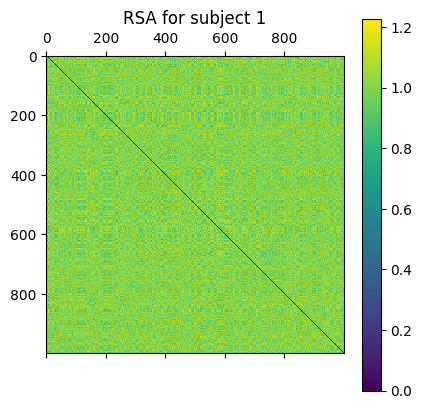

In [10]:
rdm = tripleN.compute_rdm()

plt.figure(figsize=(5,4))
plt.matshow(squareform(rdm))
plt.title(f'RSA for subject 1')
plt.colorbar()
plt.show()

In [11]:
triple_n_indices = tripleN.nsd_to_stim_index(common)

rdms_triple = [tripleN.compute_rdm(macaque=f"M{macaque}", indices=triple_n_indices) for macaque in range(1, 4)]
rdms_triple = np.vstack(rdms_triple)
tripleN_noise_ceiling = noise_ceiling(rdms_triple)
print(f"Triple-N noise ceiling lower bound: {tripleN_noise_ceiling[0]:.4f}, upper bound: {tripleN_noise_ceiling[1]:.4f}")

Triple-N noise ceiling lower bound: 0.4111, upper bound: 0.7368


# Cross Species correlations

In [12]:
for rdm in rdms_triple:
    for rdm2 in rdms_algo:
        rho_, pval = spearmanr(rdm, rdm2)
        print(f"Spearman correlation between Triple-N and Algonauts RDMs: {rho_:.4f}, p-value: {pval:.4e}")

Spearman correlation between Triple-N and Algonauts RDMs: 0.3582, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RDMs: 0.3711, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RDMs: 0.3496, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RDMs: 0.2598, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RDMs: 0.2378, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RDMs: 0.2504, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RDMs: 0.2576, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RDMs: 0.1941, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RDMs: 0.4001, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RDMs: 0.4316, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RDMs: 0.4476, p-value: 0.0000e+00
Spearman correlation between Triple-N and Algonauts RD

In [17]:
area_labels = sorted(tripleN.units["region"].unique())
print(area_labels)

['EVC', 'IT']


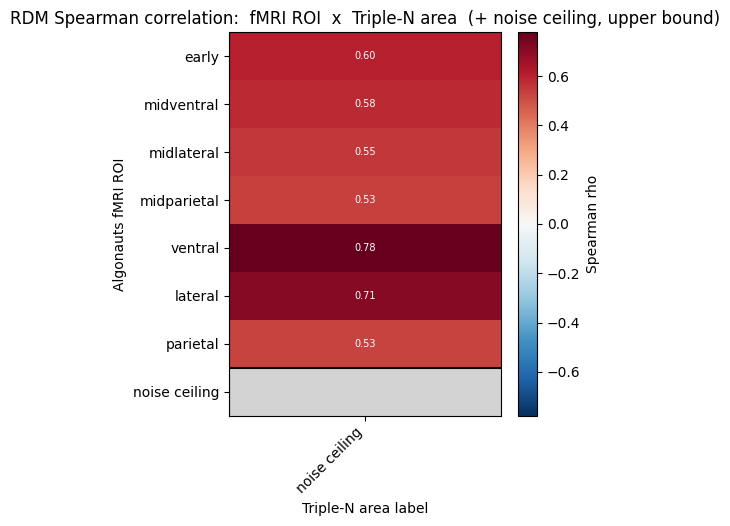

In [13]:
# RDM similarity table: every Algonauts fMRI ROI  x  every Triple-N area label, plus a
# noise-ceiling COLUMN (per ROI, across subjects) and ROW (per area label, across macaques).
# Every RDM is computed over the SAME shared stimuli (the `common` images, in one shared
# order) via each model's compute_rdm, so all RDMs line up.

ALGO_ROIS = [
    "early", "midventral", "midlateral", "midparietal",     # streams
    "ventral", "lateral", "parietal",
]
SUBJECTS = range(1, 9)  # ROI RDMs / noise ceilings are taken across these subjects

matched = [set(algonauts.shared_stimuli_indices(s, shared_ids)[0]) for s in SUBJECTS]
common = sorted(set.intersection(*matched))

# Keep only stimuli present in BOTH datasets, in one shared order, so every RDM aligns.
stim_idx = tripleN.nsd_to_stim_index(common)
keep = [k for k, s in enumerate(stim_idx) if s is not None]
common_aligned = [common[k] for k in keep]
stim_aligned = [stim_idx[k] for k in keep]

# --- Algonauts: per-subject ROI RDMs (via compute_rdm) -> group-mean + noise ceiling ---
# NOTE: compute_rdm reloads the subject fMRI on each call, so this re-reads per (subject, ROI).
algo_rdms, algo_nc = {}, {}
for roi in ALGO_ROIS:
    per_subj = [algonauts.compute_rdm(subject=s, indices=common_aligned, roi=roi) for s in SUBJECTS]
    per_subj = [r for r in per_subj if r.std() > 0]        # drop subjects where the ROI is empty
    if len(per_subj) < 2:                                  # need >=2 subjects for a noise ceiling
        continue
    per_subj = np.vstack(per_subj)
    algo_rdms[roi] = per_subj.mean(axis=0)
    algo_nc[roi] = noise_ceiling(per_subj)       # (lower, upper)

# --- Triple-N: per-area-label RDM (units pooled) + noise ceiling (across macaques) ---
macaques = sorted(tripleN.units["macaque"].unique())
area_labels = sorted(tripleN.units["region"].unique())
triple_rdms, triple_nc = {}, {}
for label in area_labels:
    try:
        triple_rdms[label] = tripleN.compute_rdm(region=label, indices=stim_aligned)
    except ValueError:
        continue                                           # fewer than 2 units for this label
    per_macaque = []
    for m in macaques:
        try:
            r = tripleN.compute_rdm(area_label=label, macaque=m, indices=stim_aligned)
        except ValueError:
            continue                                       # this macaque has too few units here
        if r.std() > 0:
            per_macaque.append(r)
    if len(per_macaque) >= 2:                              # need >=2 macaques for a noise ceiling
        triple_nc[label] = noise_ceiling(np.vstack(per_macaque))

# --- Spearman correlation between every ROI RDM and every area-label RDM ---
rois = [r for r in ALGO_ROIS if r in algo_rdms]
labels = [l for l in area_labels if l in triple_rdms]
corr = np.array([[spearmanr(algo_rdms[roi], triple_rdms[label])[0]
                  for label in labels] for roi in rois])

# --- Assemble the table with an extra noise-ceiling row + column (upper bound shown) ---
M = np.full((len(rois) + 1, len(labels) + 1), np.nan)
M[:len(rois), :len(labels)] = corr
M[:len(rois), -1] = [algo_nc[roi][1] for roi in rois]                           # ROI ceiling -> column
M[-1, :len(labels)] = [triple_nc.get(l, (np.nan, np.nan))[1] for l in labels]  # area ceiling -> row
row_labels = rois + ["noise ceiling"]
col_labels = labels + ["noise ceiling"]

# --- Table plot (annotated heatmap) ---
vmax = np.nanmax(np.abs(M))
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")                                  # NaN cells (e.g. the corner) shown gray
fig, ax = plt.subplots(figsize=(1.1 * len(col_labels) + 4, 0.42 * len(row_labels) + 2))
im = ax.imshow(M, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=45, ha="right")
ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
ax.axvline(len(labels) - 0.5, color="k", lw=1.5)          # separate the noise-ceiling row/col
ax.axhline(len(rois) - 0.5, color="k", lw=1.5)
ax.set_xlabel("Triple-N area label")
ax.set_ylabel("Algonauts fMRI ROI")
ax.set_title("RDM Spearman correlation:  fMRI ROI  x  Triple-N area  (+ noise ceiling, upper bound)")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.6 * vmax else "black")
fig.colorbar(im, ax=ax, label="Spearman rho")
plt.tight_layout()
plt.show()

In [14]:
fig.savefig(
    "../figures/rdm_roi_x_area_heatmap.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)